<a href="https://colab.research.google.com/github/chatgptkashmir/YAG-Power-Traces-Analysis/blob/main/YAG_Power_Traces_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload all YAG CSV files now.
Example: 850v1Hz.csv, 850v3Hz.csv, ..., 1000v5Hz.csv



Saving 850v1Hz.csv to 850v1Hz (1).csv
Saving 850v3Hz.csv to 850v3Hz (1).csv
Saving 850v5Hz.csv to 850v5Hz (1).csv
Saving 900v1Hz.csv to 900v1Hz (1).csv
Saving 900v3Hz.csv to 900v3Hz (1).csv
Saving 900v5Hz.csv to 900v5Hz (1).csv
Saving 950v1Hz.csv to 950v1Hz (1).csv
Saving 950v3Hz.csv to 950v3Hz (1).csv
Saving 950v5Hz.csv to 950v5Hz (1).csv
Saving 1000v1Hz.csv to 1000v1Hz (1).csv
Saving 1000v3Hz.csv to 1000v3Hz (1).csv
Saving 1000v5Hz.csv to 1000v5Hz (1).csv

12 CSV file(s) uploaded successfully.


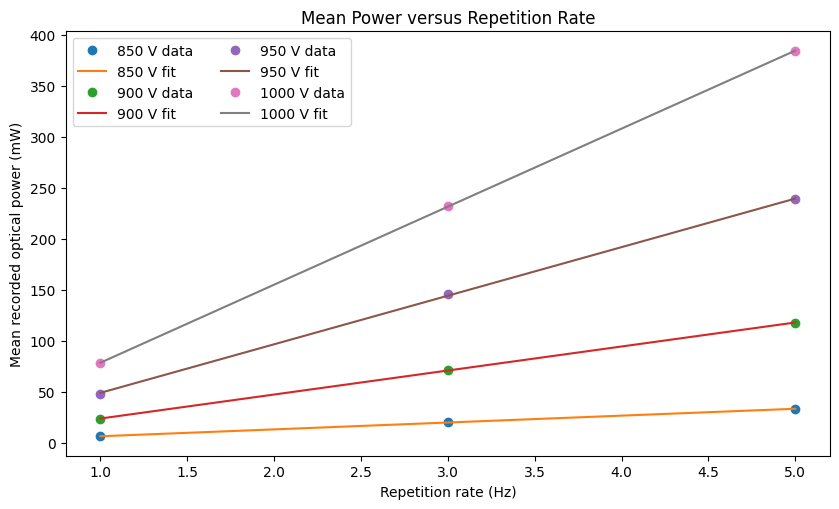

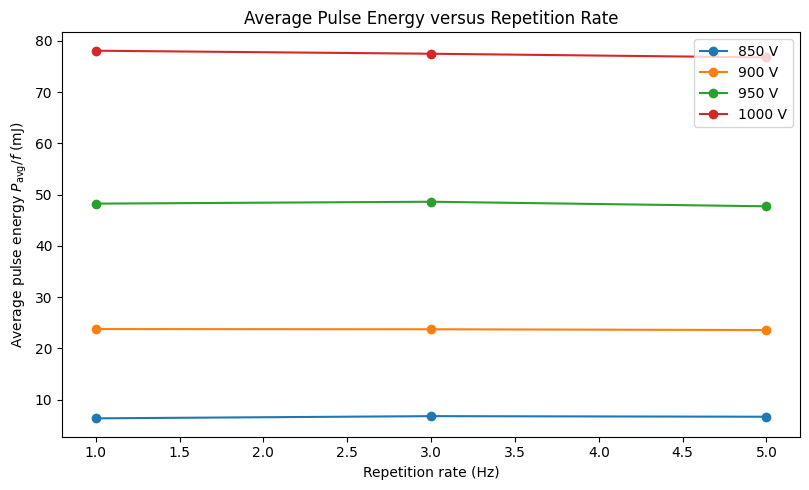

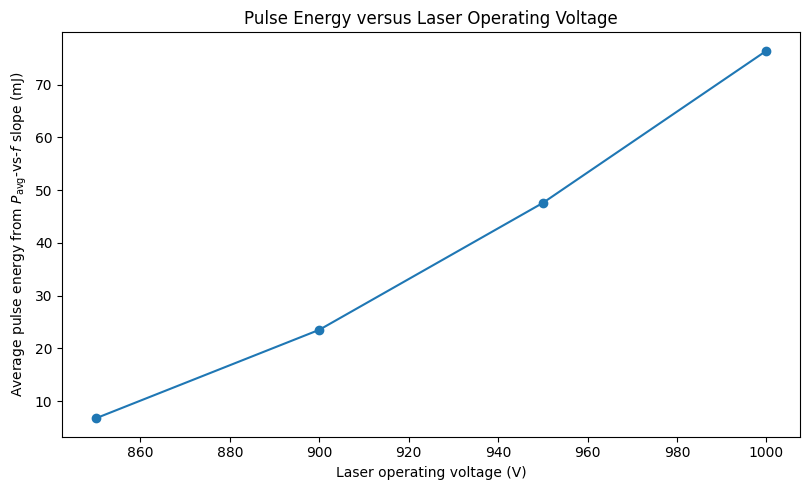

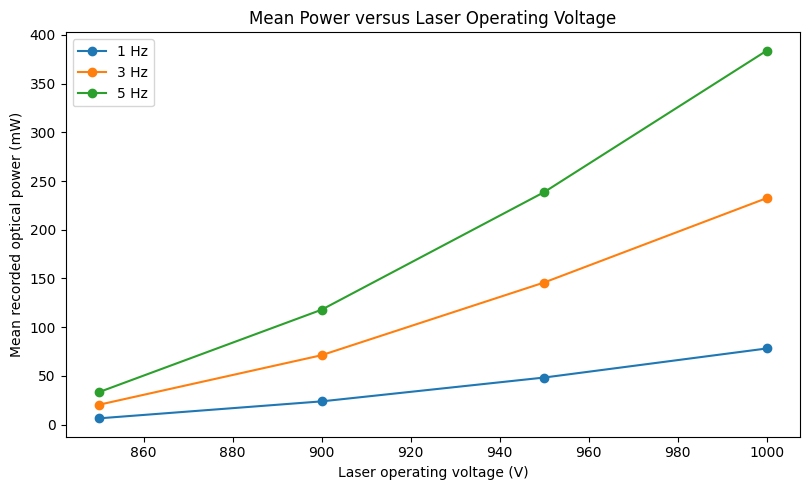

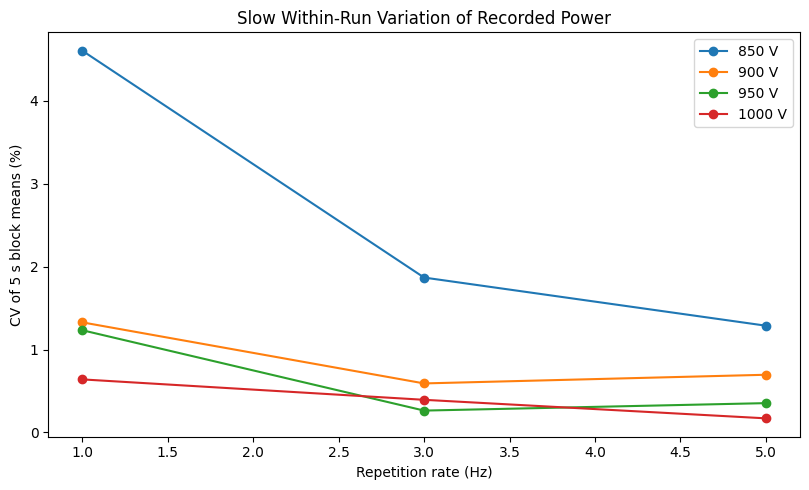

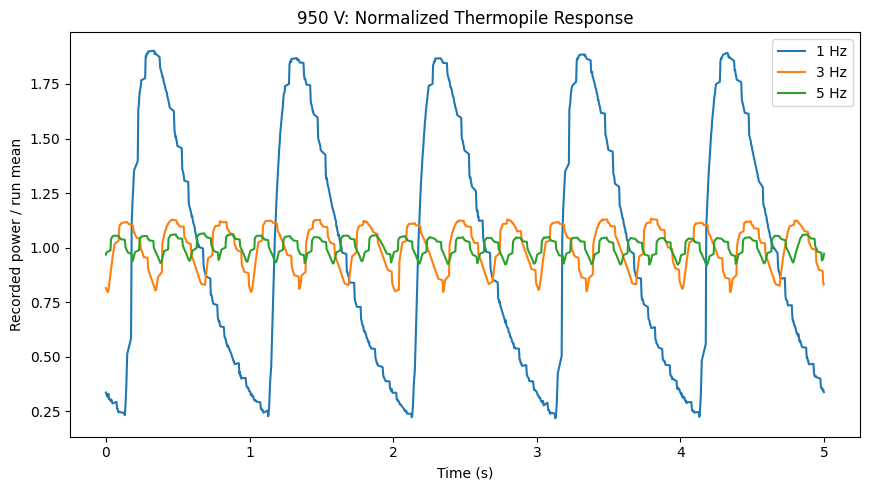


CONDITION-BY-CONDITION SUMMARY


,Voltage_V,RepetitionRate_Hz,MeanPower_mW,RecordedMinimum_mW,RecordedMaximum_mW,AveragePulseEnergy_mJ_Pavg_over_f,FiveSecondBlockCV_percent
0,850,1.0,6.3437,-0.5670,14.486,6.3437,4.6017
1,850,3.0,20.3154,14.5070,24.571,6.7718,1.8674
2,850,5.0,33.2820,28.6530,36.989,6.6564,1.2872
3,900,1.0,23.7593,3.7523,47.852,23.7593,1.3273
4,900,3.0,71.1530,55.1300,82.688,23.7177,0.5913
5,900,5.0,117.8401,103.9600,127.330,23.5680,0.6957
6,950,1.0,48.2269,9.2810,94.566,48.2269,1.2323
7,950,3.0,145.7914,114.0200,166.910,48.5971,0.2638
8,950,5.0,238.5332,219.2000,255.160,47.7066,0.3537
9,1000,1.0,78.0571,15.3500,149.440,78.0571,0.6398



PULSE ENERGY FROM P_avg = E_p f + P_0


,Voltage_V,PulseEnergyFromSlope_mJ,Intercept_mW,R_squared,SlopeFitSE_mJ,Mean_Pavg_over_f_mJ,CrossRateCV_percent
0,850,6.7346,-0.2233,0.9995,0.1451,6.5906,3.3605
1,900,23.5202,0.3568,1.0000,0.1020,23.6817,0.4247
2,950,47.5766,1.4541,0.9998,0.6961,48.1769,0.9286
3,1000,76.4264,2.1289,1.0000,0.4314,77.4260,0.8438



INSTRUMENT INFORMATION READ FROM CSV HEADERS


,Filename,Voltage_V,RepetitionRate_Hz,Sensor,SensorType,PowerMeter,Wavelength,Range
0,850v1Hz (1).csv,850,1.0,S425C-L,Thermopile,PM100D,532 nm,Auto
1,850v3Hz (1).csv,850,3.0,S425C-L,Thermopile,PM100D,532 nm,Auto
2,850v5Hz (1).csv,850,5.0,S425C-L,Thermopile,PM100D,532 nm,Auto
3,900v1Hz (1).csv,900,1.0,S425C-L,Thermopile,PM100D,532 nm,Auto
4,900v3Hz (1).csv,900,3.0,S425C-L,Thermopile,PM100D,532 nm,Auto
5,900v5Hz (1).csv,900,5.0,S425C-L,Thermopile,PM100D,532 nm,Auto
6,950v1Hz (1).csv,950,1.0,S425C-L,Thermopile,PM100D,532 nm,Auto
7,950v3Hz (1).csv,950,3.0,S425C-L,Thermopile,PM100D,532 nm,Auto
8,950v5Hz (1).csv,950,5.0,S425C-L,Thermopile,PM100D,532 nm,Auto
9,1000v1Hz (1).csv,1000,1.0,S425C-L,Thermopile,PM100D,532 nm,Auto



MAIN RESULTS

850 V:  pulse energy from slope = 6.735 mJ,  R^2 = 0.999536
900 V:  pulse energy from slope = 23.520 mJ,  R^2 = 0.999981
950 V:  pulse energy from slope = 47.577 mJ,  R^2 = 0.999786
1000 V:  pulse energy from slope = 76.426 mJ,  R^2 = 0.999968

ANALYSIS COMPLETE

All files were saved in:
/content/Beam Analysis_YAG

ZIP file created:
/content/Beam_Analysis_YAG_results.zip

The ZIP file contains:
- uploaded CSV files
- all individual trace plots
- summary CSV tables
- mean-power plots
- pulse-energy plots
- stability plot
- normalized detector-response plot



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# ==============================================================
# ONE-CELL GOOGLE COLAB SCRIPT
# YAG THERMAL POWER-TRACE ANALYSIS
# ==============================================================
#
# HOW TO USE
# ----------
# 1. Open a new Google Colab notebook.
# 2. Paste this entire script into ONE cell.
# 3. Run the cell.
# 4. Select and upload all of your CSV files.
# 5. The analysis runs automatically.
# 6. A ZIP file containing all plots and CSV summaries is downloaded.
#
# Expected filename style:
#   850v1Hz.csv
#   850v3Hz.csv
#   ...
#   1000v5Hz.csv
#
# The code automatically reads the voltage and repetition rate from
# each filename, so additional voltage/rate combinations can also be used.
#
# IMPORTANT:
# The recorded trace is treated as the slow thermal-detector / meter response.
# The code does NOT interpret its width as the <50 ns optical pulse width.
#
# ==============================================================

from pathlib import Path
from io import StringIO
import re
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display, Image


# ==============================================================
# 1. SETTINGS
# ==============================================================

OUTPUT_FOLDER = Path("/content/Beam Analysis_YAG")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

FIG_DPI = 300
BLOCK_LENGTH_S = 5.0


# ==============================================================
# 2. UPLOAD CSV FILES
# ==============================================================

print("Upload all YAG CSV files now.")
print("Example: 850v1Hz.csv, 850v3Hz.csv, ..., 1000v5Hz.csv\n")

uploaded = files.upload()

csv_names = [
    name for name in uploaded.keys()
    if name.lower().endswith(".csv")
]

if len(csv_names) == 0:
    raise RuntimeError("No CSV files were uploaded.")

# Save uploaded files in the output folder
for name in csv_names:
    (OUTPUT_FOLDER / Path(name).name).write_bytes(uploaded[name])

print(f"\n{len(csv_names)} CSV file(s) uploaded successfully.")


# ==============================================================
# 3. HELPER FUNCTIONS
# ==============================================================

def read_opm_csv(path):
    """
    Read a Thorlabs OPM CSV file.

    Returns
    -------
    voltage : int
    repetition_rate : int
    metadata : dict
    df : pandas.DataFrame
         columns: time_ms, power_W, time_s
    """

    text = path.read_text(
        encoding="utf-8-sig",
        errors="replace"
    )

    lines = text.splitlines()

    # ----------------------------------------------------------
    # Metadata
    # ----------------------------------------------------------
    metadata = {}

    for line in lines:
        if line.strip() == "--Graph Data--":
            break

        if "," in line:
            key, value = line.split(",", 1)
            metadata[key.strip()] = value.strip()

    # ----------------------------------------------------------
    # Find numerical data header
    # ----------------------------------------------------------
    header_index = None

    for i, line in enumerate(lines):
        compact = line.replace(" ", "").lower()

        if compact == "time(ms),power(w)":
            header_index = i
            break

    if header_index is None:
        raise ValueError(
            f'Could not find "Time (ms),Power (W)" in {path.name}'
        )

    df = pd.read_csv(
        StringIO("\n".join(lines[header_index:]))
    )

    if len(df.columns) < 2:
        raise ValueError(
            f"Could not read two numerical columns from {path.name}"
        )

    df = df.iloc[:, :2].copy()
    df.columns = ["time_ms", "power_W"]

    df["time_ms"] = pd.to_numeric(
        df["time_ms"],
        errors="coerce"
    )

    df["power_W"] = pd.to_numeric(
        df["power_W"],
        errors="coerce"
    )

    df = df.dropna(
        subset=["time_ms", "power_W"]
    ).reset_index(drop=True)

    if len(df) < 2:
        raise ValueError(
            f"Not enough numerical data in {path.name}"
        )

    df["time_s"] = df["time_ms"] / 1000.0

    # ----------------------------------------------------------
    # Read voltage and repetition rate from filename
    # ----------------------------------------------------------
    match = re.search(
        r"(\d+)\s*[vV].*?(\d+(?:\.\d+)?)\s*[hH][zZ]",
        path.stem
    )

    if match is None:
        raise ValueError(
            f"Could not determine voltage and repetition rate "
            f"from filename: {path.name}\n"
            f"Use names such as 850v1Hz.csv."
        )

    voltage = int(match.group(1))
    repetition_rate = float(match.group(2))

    return voltage, repetition_rate, metadata, df


def linear_fit(x, y):
    """
    Fit y = slope*x + intercept and return:
        slope, intercept, R^2, slope standard error
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    slope, intercept = np.polyfit(x, y, 1)

    y_fit = slope * x + intercept

    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)

    if ss_tot > 0:
        r_squared = 1.0 - ss_res / ss_tot
    else:
        r_squared = np.nan

    dof = len(x) - 2

    if dof > 0:
        residual_variance = ss_res / dof
        denominator = np.sum((x - np.mean(x))**2)

        if denominator > 0:
            slope_se = np.sqrt(
                residual_variance / denominator
            )
        else:
            slope_se = np.nan
    else:
        slope_se = np.nan

    return slope, intercept, r_squared, slope_se


def five_second_block_statistics(
    time_s,
    power_W,
    block_length_s=5.0
):
    """
    Calculate mean power in consecutive time blocks.

    The coefficient of variation of these block means is used only
    as a measure of slow within-run variation.
    """

    t = np.asarray(time_s, dtype=float)
    p = np.asarray(power_W, dtype=float)

    t = t - t[0]

    duration = t[-1] - t[0]

    n_blocks = int(duration // block_length_s)

    block_means = []

    for i in range(n_blocks):

        start = i * block_length_s
        stop = (i + 1) * block_length_s

        mask = (t >= start) & (t < stop)

        if np.count_nonzero(mask) >= 2:
            block_means.append(
                np.mean(p[mask])
            )

    block_means = np.asarray(
        block_means,
        dtype=float
    )

    if (
        len(block_means) >= 2
        and np.mean(block_means) != 0
    ):
        cv_percent = (
            100.0
            * np.std(block_means, ddof=1)
            / np.mean(block_means)
        )
    else:
        cv_percent = np.nan

    return block_means, cv_percent


def save_figure(path):
    plt.tight_layout()
    plt.savefig(
        path,
        dpi=FIG_DPI,
        bbox_inches="tight"
    )


# ==============================================================
# 4. READ ALL FILES AND CALCULATE BASIC RESULTS
# ==============================================================

datasets = {}
summary_rows = []
block_rows = []
metadata_rows = []

for name in sorted(csv_names):

    path = OUTPUT_FOLDER / Path(name).name

    voltage, rep_rate, metadata, df = read_opm_csv(path)

    key = (voltage, rep_rate)

    datasets[key] = {
        "filename": path.name,
        "metadata": metadata,
        "data": df
    }

    duration_s = (
        df["time_s"].iloc[-1]
        - df["time_s"].iloc[0]
    )

    mean_power_W = df["power_W"].mean()
    minimum_power_W = df["power_W"].min()
    maximum_power_W = df["power_W"].max()
    sample_sd_W = df["power_W"].std(ddof=0)

    stored_sample_rate_Hz = (
        (len(df) - 1) / duration_s
        if duration_s > 0
        else np.nan
    )

    block_means_W, block_cv_percent = (
        five_second_block_statistics(
            df["time_s"],
            df["power_W"],
            BLOCK_LENGTH_S
        )
    )

    # ----------------------------------------------------------
    # Average energy per laser pulse
    #
    #   E_p = P_avg / f
    #
    # W / Hz = J
    #
    # Multiply by 1000 for mJ.
    # ----------------------------------------------------------
    pulse_energy_mJ = (
        1000.0
        * mean_power_W
        / rep_rate
    )

    summary_rows.append({
        "Voltage_V":
            voltage,

        "RepetitionRate_Hz":
            rep_rate,

        "Duration_s":
            duration_s,

        "NumberOfSamples":
            len(df),

        "StoredSampleRate_Hz":
            stored_sample_rate_Hz,

        "MeanPower_mW":
            1000.0 * mean_power_W,

        "RecordedMinimum_mW":
            1000.0 * minimum_power_W,

        "RecordedMaximum_mW":
            1000.0 * maximum_power_W,

        "RawSampleSD_mW":
            1000.0 * sample_sd_W,

        "AveragePulseEnergy_mJ_Pavg_over_f":
            pulse_energy_mJ,

        "FiveSecondBlockCV_percent":
            block_cv_percent
    })

    for block_index, value_W in enumerate(
        block_means_W
    ):

        block_rows.append({
            "Voltage_V":
                voltage,

            "RepetitionRate_Hz":
                rep_rate,

            "BlockIndex":
                block_index,

            "BlockStart_s":
                block_index * BLOCK_LENGTH_S,

            "BlockMeanPower_mW":
                1000.0 * value_W
        })

    metadata_rows.append({
        "Filename":
            path.name,

        "Voltage_V":
            voltage,

        "RepetitionRate_Hz":
            rep_rate,

        "Sensor":
            metadata.get("Sensor", ""),

        "SensorType":
            metadata.get("Sensor Type", ""),

        "PowerMeter":
            metadata.get("Power Meter", ""),

        "Wavelength":
            metadata.get("Wavelength", ""),

        "Range":
            metadata.get("Range", "")
    })


summary = pd.DataFrame(
    summary_rows
).sort_values(
    ["Voltage_V", "RepetitionRate_Hz"]
).reset_index(drop=True)

block_summary = pd.DataFrame(block_rows)

metadata_table = pd.DataFrame(
    metadata_rows
).sort_values(
    ["Voltage_V", "RepetitionRate_Hz"]
).reset_index(drop=True)


# ==============================================================
# 5. SAVE NUMERICAL TABLES
# ==============================================================

summary.to_csv(
    OUTPUT_FOLDER
    / "YAG_thermal_trace_condition_summary.csv",
    index=False
)

block_summary.to_csv(
    OUTPUT_FOLDER
    / "YAG_5s_block_means.csv",
    index=False
)

metadata_table.to_csv(
    OUTPUT_FOLDER
    / "YAG_instrument_metadata.csv",
    index=False
)


# ==============================================================
# 6. CREATE ONE FIGURE FOR EACH RAW TRACE
# ==============================================================

for _, row in summary.iterrows():

    voltage = int(row["Voltage_V"])
    rep_rate = float(
        row["RepetitionRate_Hz"]
    )

    df = datasets[
        (voltage, rep_rate)
    ]["data"]

    t = (
        df["time_s"]
        - df["time_s"].iloc[0]
    )

    power_mW = (
        1000.0
        * df["power_W"]
    )

    mean_power_mW = row["MeanPower_mW"]

    plt.figure(figsize=(9.0, 4.8))

    plt.plot(
        t,
        power_mW,
        linewidth=0.9,
        label="Recorded response"
    )

    plt.axhline(
        mean_power_mW,
        linestyle="--",
        linewidth=1.0,
        label=f"Mean = {mean_power_mW:.3f} mW"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("Recorded power (mW)")

    plt.title(
        f"YAG Thermal-Power Trace: "
        f"{voltage} V, {rep_rate:g} Hz"
    )

    plt.legend()

    output_name = (
        f"trace_{voltage}V_{rep_rate:g}Hz.png"
    )

    save_figure(
        OUTPUT_FOLDER / output_name
    )

    plt.close()


# ==============================================================
# 7. FIT MEAN POWER VS REPETITION RATE
#
#    P_avg = E_p * f + P_0
#
#    Slope = average pulse energy
# ==============================================================

fit_rows = []

plt.figure(figsize=(8.5, 5.2))

for voltage, group in summary.groupby(
    "Voltage_V"
):

    group = group.sort_values(
        "RepetitionRate_Hz"
    )

    x = group[
        "RepetitionRate_Hz"
    ].to_numpy(dtype=float)

    y_W = (
        group[
            "MeanPower_mW"
        ].to_numpy(dtype=float)
        / 1000.0
    )

    # Need at least two repetition rates for a line fit
    if len(x) >= 2:

        slope, intercept, r_squared, slope_se = (
            linear_fit(x, y_W)
        )

        x_fit = np.linspace(
            np.min(x),
            np.max(x),
            100
        )

        y_fit_W = (
            slope * x_fit
            + intercept
        )

        plt.plot(
            x,
            1000.0 * y_W,
            "o",
            label=f"{int(voltage)} V data"
        )

        plt.plot(
            x_fit,
            1000.0 * y_fit_W,
            "-",
            label=f"{int(voltage)} V fit"
        )

        mean_energy_mJ = group[
            "AveragePulseEnergy_mJ_Pavg_over_f"
        ].mean()

        if len(group) >= 2:
            cross_rate_cv_percent = (
                100.0
                * group[
                    "AveragePulseEnergy_mJ_Pavg_over_f"
                ].std(ddof=1)
                / mean_energy_mJ
            )
        else:
            cross_rate_cv_percent = np.nan

        fit_rows.append({
            "Voltage_V":
                int(voltage),

            "PulseEnergyFromSlope_mJ":
                1000.0 * slope,

            "Intercept_mW":
                1000.0 * intercept,

            "R_squared":
                r_squared,

            "SlopeFitSE_mJ":
                1000.0 * slope_se,

            "Mean_Pavg_over_f_mJ":
                mean_energy_mJ,

            "CrossRateCV_percent":
                cross_rate_cv_percent
        })

    else:

        plt.plot(
            x,
            1000.0 * y_W,
            "o",
            label=f"{int(voltage)} V"
        )


plt.xlabel("Repetition rate (Hz)")
plt.ylabel("Mean recorded optical power (mW)")
plt.title("Mean Power versus Repetition Rate")
plt.legend(ncol=2)

save_figure(
    OUTPUT_FOLDER
    / "mean_power_vs_repetition_rate.png"
)

plt.show()
plt.close()


fit_summary = pd.DataFrame(
    fit_rows
)

fit_summary.to_csv(
    OUTPUT_FOLDER
    / "YAG_pulse_energy_voltage_summary.csv",
    index=False
)


# ==============================================================
# 8. PULSE ENERGY P_avg / f VS REPETITION RATE
# ==============================================================

plt.figure(figsize=(8.2, 5.0))

for voltage, group in summary.groupby(
    "Voltage_V"
):

    group = group.sort_values(
        "RepetitionRate_Hz"
    )

    plt.plot(
        group["RepetitionRate_Hz"],
        group[
            "AveragePulseEnergy_mJ_Pavg_over_f"
        ],
        "o-",
        label=f"{int(voltage)} V"
    )

plt.xlabel("Repetition rate (Hz)")
plt.ylabel(
    r"Average pulse energy "
    r"$P_{\mathrm{avg}}/f$ (mJ)"
)
plt.title(
    "Average Pulse Energy versus Repetition Rate"
)
plt.legend()

save_figure(
    OUTPUT_FOLDER
    / "pulse_energy_vs_repetition_rate.png"
)

plt.show()
plt.close()


# ==============================================================
# 9. PULSE ENERGY FROM SLOPE VS VOLTAGE
# ==============================================================

if not fit_summary.empty:

    plt.figure(figsize=(8.2, 5.0))

    plt.plot(
        fit_summary["Voltage_V"],
        fit_summary[
            "PulseEnergyFromSlope_mJ"
        ],
        "o-"
    )

    plt.xlabel(
        "Laser operating voltage (V)"
    )

    plt.ylabel(
        "Average pulse energy from "
        r"$P_{\mathrm{avg}}$-vs-$f$ slope (mJ)"
    )

    plt.title(
        "Pulse Energy versus Laser Operating Voltage"
    )

    save_figure(
        OUTPUT_FOLDER
        / "pulse_energy_vs_voltage.png"
    )

    plt.show()
    plt.close()


# ==============================================================
# 10. MEAN POWER VS VOLTAGE
# ==============================================================

plt.figure(figsize=(8.2, 5.0))

for rep_rate, group in summary.groupby(
    "RepetitionRate_Hz"
):

    group = group.sort_values(
        "Voltage_V"
    )

    plt.plot(
        group["Voltage_V"],
        group["MeanPower_mW"],
        "o-",
        label=f"{rep_rate:g} Hz"
    )

plt.xlabel("Laser operating voltage (V)")
plt.ylabel("Mean recorded optical power (mW)")
plt.title(
    "Mean Power versus Laser Operating Voltage"
)
plt.legend()

save_figure(
    OUTPUT_FOLDER
    / "mean_power_vs_voltage.png"
)

plt.show()
plt.close()


# ==============================================================
# 11. SLOW WITHIN-RUN STABILITY
# ==============================================================

plt.figure(figsize=(8.2, 5.0))

for voltage, group in summary.groupby(
    "Voltage_V"
):

    group = group.sort_values(
        "RepetitionRate_Hz"
    )

    plt.plot(
        group["RepetitionRate_Hz"],
        group[
            "FiveSecondBlockCV_percent"
        ],
        "o-",
        label=f"{int(voltage)} V"
    )

plt.xlabel("Repetition rate (Hz)")
plt.ylabel("CV of 5 s block means (%)")
plt.title(
    "Slow Within-Run Variation of Recorded Power"
)
plt.legend()

save_figure(
    OUTPUT_FOLDER
    / "stability_cv_vs_repetition_rate.png"
)

plt.show()
plt.close()


# ==============================================================
# 12. REPRESENTATIVE NORMALIZED DETECTOR RESPONSE
#
# Prefer 950 V if available. Otherwise use the middle voltage.
# ==============================================================

available_voltages = sorted(
    summary["Voltage_V"].unique()
)

if 950 in available_voltages:
    representative_voltage = 950
else:
    representative_voltage = (
        available_voltages[
            len(available_voltages) // 2
        ]
    )

representative_rates = sorted(
    summary.loc[
        summary["Voltage_V"]
        == representative_voltage,
        "RepetitionRate_Hz"
    ].unique()
)

if len(representative_rates) >= 1:

    plt.figure(figsize=(8.8, 5.0))

    for rep_rate in representative_rates:

        df = datasets[
            (
                int(representative_voltage),
                float(rep_rate)
            )
        ]["data"]

        t = (
            df["time_s"]
            - df["time_s"].iloc[0]
        )

        mask = t <= 5.0

        run_mean = df["power_W"].mean()

        if run_mean != 0:
            normalized = (
                df.loc[mask, "power_W"]
                / run_mean
            )

            plt.plot(
                t[mask],
                normalized,
                label=f"{rep_rate:g} Hz"
            )

    plt.xlabel("Time (s)")
    plt.ylabel(
        "Recorded power / run mean"
    )

    plt.title(
        f"{representative_voltage} V: "
        "Normalized Thermopile Response"
    )

    plt.legend()

    save_figure(
        OUTPUT_FOLDER
        / "representative_normalized_response.png"
    )

    plt.show()
    plt.close()


# ==============================================================
# 13. PRINT RESULTS
# ==============================================================

print("\n" + "=" * 80)
print("CONDITION-BY-CONDITION SUMMARY")
print("=" * 80)

display_columns = [
    "Voltage_V",
    "RepetitionRate_Hz",
    "MeanPower_mW",
    "RecordedMinimum_mW",
    "RecordedMaximum_mW",
    "AveragePulseEnergy_mJ_Pavg_over_f",
    "FiveSecondBlockCV_percent"
]

display(
    summary[
        display_columns
    ].round(4)
)


if not fit_summary.empty:

    print("\n" + "=" * 80)
    print(
        "PULSE ENERGY FROM "
        "P_avg = E_p f + P_0"
    )
    print("=" * 80)

    display(
        fit_summary.round(4)
    )


print("\n" + "=" * 80)
print("INSTRUMENT INFORMATION READ FROM CSV HEADERS")
print("=" * 80)

display(metadata_table)


# ==============================================================
# 14. QUICK TEXT SUMMARY
# ==============================================================

print("\nMAIN RESULTS\n")

for voltage in sorted(
    summary["Voltage_V"].unique()
):

    if not fit_summary.empty and (
        voltage in fit_summary["Voltage_V"].values
    ):

        row = fit_summary.loc[
            fit_summary["Voltage_V"]
            == voltage
        ].iloc[0]

        print(
            f"{int(voltage)} V:"
            f"  pulse energy from slope = "
            f"{row['PulseEnergyFromSlope_mJ']:.3f} mJ,"
            f"  R^2 = {row['R_squared']:.6f}"
        )

    else:

        group = summary.loc[
            summary["Voltage_V"]
            == voltage
        ]

        print(
            f"{int(voltage)} V:"
            f"  mean Pavg/f = "
            f"{group['AveragePulseEnergy_mJ_Pavg_over_f'].mean():.3f} mJ"
        )


# ==============================================================
# 15. CREATE ZIP FILE WITH ALL RESULTS
# ==============================================================

zip_path = Path(
    "/content/Beam_Analysis_YAG_results.zip"
)

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(
    zip_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as archive:

    for path in sorted(
        OUTPUT_FOLDER.iterdir()
    ):

        if path.is_file():

            archive.write(
                path,
                arcname=(
                    f"Beam Analysis_YAG/"
                    f"{path.name}"
                )
            )


# ==============================================================
# 16. FINISH
# ==============================================================

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

print(
    f"\nAll files were saved in:\n"
    f"{OUTPUT_FOLDER}"
)

print(
    f"\nZIP file created:\n"
    f"{zip_path}"
)

print(
    "\nThe ZIP file contains:"
    "\n- uploaded CSV files"
    "\n- all individual trace plots"
    "\n- summary CSV tables"
    "\n- mean-power plots"
    "\n- pulse-energy plots"
    "\n- stability plot"
    "\n- normalized detector-response plot"
)

print(
    "\nDownloading ZIP file now..."
)

files.download(
    str(zip_path)
)

